# DeepSeek Coder 6.7b Instruct - HumanEval Benchmark Pipeline

This notebook implements a pipeline to benchmark the `deepseek-ai/deepseek-coder-6.7b-instruct` model on the HumanEval dataset using various prompting strategies:
1. **Zero-shot**
2. **Few-shot**
3. **Chain of Thought (CoT)**
4. **Hint-based**

Finally, we calculate the Pass@1 score using a custom serial evaluator (Windows-compatible).

In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from human_eval.data import write_jsonl, read_problems
from tqdm import tqdm
import json
import os
import sys

c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Model Loading
We load the model with 4-bit quantization to save memory. If you have enough VRAM (24GB+), you can remove `load_in_4bit=True`.

In [2]:
model_name = "deepseek-ai/deepseek-coder-6.7b-instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)
model.eval()
print("Model loaded successfully!")

The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
Loading checkpoint shards: 100%|██████████| 2/2 [00:24<00:00, 12.23s/it]


Model loaded successfully!


## 2. Prompting Strategies
Define functions to construct prompts based on the selected strategy.

In [3]:
def get_prompt(arm_id, problem):
    base_instruction = "You are an expert Python programmer. Complete the function by writing ONLY the code that goes inside the function body. Do NOT repeat the function signature, do NOT add comments, do NOT write tests.\n\n"
    
    if arm_id == 0:  # zero_shot
        prompt_content = base_instruction + f"Complete this function:\n\n{problem['prompt']}"
    
    elif arm_id == 1:  # few_shot
        examples = '''
        Example 1:
        Problem: 
        def add(a, b):
            """Returns the sum of a and b"""
            
        Solution:
            return a + b

        Example 2:
        Problem:
        def reverse_string(s):
            """Reverses the input string"""
            
        Solution:
            return s[::-1]

        Example 3:
        Problem:
        def find_max(lst):
            """Finds the maximum value in a list"""
            
        Solution:
            return max(lst)
        '''
        prompt_content = base_instruction + f"Here are examples of completed functions:\n{examples}\n\nNow complete this function:\n\n{problem['prompt']}"
    
    elif arm_id == 2:  # cot
        prompt_content = f"Think step by step about how to solve this problem, then write the code. First, reason about the approach, then provide the code.\n\nProblem:\n{problem['prompt']}\n\nReasoning: Let me think about this step by step. "
    
    elif arm_id == 3:  # hint
        # Problem-specific hints based on content
        prompt_text = problem['prompt'].lower()
        if any(word in prompt_text for word in ['sort', 'sorted', 'order']):
            hint = "Hint: Consider efficient sorting algorithms and time complexity."
        elif any(word in prompt_text for word in ['tree', 'node', 'binary']):
            hint = "Hint: Consider recursion or iterative traversal for tree structures."
        elif any(word in prompt_text for word in ['string', 'text', 'character']):
            hint = "Hint: Consider string manipulation methods and edge cases like empty strings."
        else:
            hint = "Hint: Consider edge cases and efficient data structures."
        
        prompt_content = base_instruction + f"{hint}\n\nComplete this function:\n\n{problem['prompt']}"
    
    messages = [{'role': 'user', 'content': prompt_content}]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

## 3. Generation Pipeline
Iterate through HumanEval problems and generate solutions.

In [4]:
def generate_fixed_strategy(problems, arm_id):
    """Generate solutions dengan fixed strategy (tanpa features/bandit)"""
    torch.cuda.empty_cache()
    gc.collect()
    
    samples = []
    print(f"Generating with fixed arm {arm_id}...")
    
    for task_id, problem in tqdm(problems.items(), desc="Generating"):
        # LANGSUNG gunakan arm_id tanpa extract features
        prompt = get_prompt(arm_id, problem)
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048).to(model.device)
        
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=512,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
        
        generated = tokenizer.decode(outputs[0][inputs['input_ids'].shape[-1]:], skip_special_tokens=True).strip()
        
        # Extract code
        if "```python" in generated:
            code = generated.split("```python")[1].split("```")[0].strip()
        elif "```" in generated:
            code = generated.split("```")[1].split("```")[0].strip()
        else:
            if "Reasoning:" in generated:
                code_part = generated.split("Reasoning:")[-1]
                lines = [line for line in code_part.split('\n') if line.strip() and not line.strip().startswith(('#', '"'))]
                code = '\n'.join(lines[-5:])
            else:
                code = generated
        
        sample = {
            "task_id": task_id,
            "completion": code,
            "arm": arm_id,  # Simpan arm_id untuk tracking
        }
        samples.append(sample)
    
    return samples

## 4. Custom Evaluation (Windows Compatible)
Since standard evaluation libraries often fail on Windows due to multiprocessing issues, we define a custom serial evaluator.

In [5]:
# 4. Custom Evaluation (Windows Compatible + Live Progress + TIMEOUT) — FIX INFINITE LOOP
from tqdm import tqdm
import threading
import sys

def run_with_timeout(code, timeout_seconds=10):
    """Execute code with timeout (Windows-compatible using threading)"""
    result = {'success': False, 'error': None}
    
    def target():
        try:
            exec_globals = {}
            exec(code, exec_globals)
            result['success'] = True
        except Exception as e:
            result['error'] = e
    
    thread = threading.Thread(target=target)
    thread.daemon = True
    thread.start()
    thread.join(timeout_seconds)
    
    if thread.is_alive():
        # Thread still running = timeout
        return False, 'TIMEOUT'
    
    return result['success'], result.get('error')

def evaluate_functional_correctness_custom(samples, problems, timeout=10):
    passed = 0
    total = len(samples)
    
    print(f"Evaluating {total} samples (timeout: {timeout}s per test)...\n")
    
    pbar = tqdm(samples, desc="Evaluating", leave=True)
    
    for i, sample in enumerate(pbar):
        task_id = sample['task_id']
        completion = sample['completion']
        problem = problems[task_id]
        
        full_code = (
            problem['prompt'] + 
            completion + 
            "\n" + 
            problem['test'] + 
            f"\ncheck({problem['entry_point']})"
        )
        
        # Run with timeout
        success, error = run_with_timeout(full_code, timeout)
        
        if success:
            passed += 1
            pbar.write(f"  [{i+1:3d}/{total}] {task_id} → PASS")
        elif error == 'TIMEOUT':
            pbar.write(f"  [{i+1:3d}/{total}] {task_id} → TIMEOUT (infinite loop?)")
        else:
            pbar.write(f"  [{i+1:3d}/{total}] {task_id} → FAIL")
        
        current_score = (passed / (i + 1)) * 100
        pbar.set_postfix({
            "Live Pass@1": f"{current_score:5.1f}%",
            "Passed": f"{passed}/{i+1}"
        })
    
    final_score = (passed / total) * 100 if total > 0 else 0.0
    print(f"\nEVALUASI SELESAI → Pass@1: {final_score:5.1f}%  ({passed}/{total})\n")
    
    return {"pass@1": final_score}

## 5. Execution & Benchmark
Run the benchmark for each strategy using the custom evaluator.

In [ ]:
import os
import urllib.request
import torch
import gc
import random

HUMAN_EVAL_URL = "https://github.com/openai/human-eval/raw/master/data/HumanEval.jsonl.gz"
LOCAL_EVAL_FILE = "HumanEval.jsonl.gz"

if not os.path.exists(LOCAL_EVAL_FILE):
    print("Downloading HumanEval dataset...")
    urllib.request.urlretrieve(HUMAN_EVAL_URL, LOCAL_EVAL_FILE)
    print("Downloaded.")

problems = read_problems(LOCAL_EVAL_FILE)
problems = dict(list(problems.items()))  
problem_items = list(problems.items())
random.seed(42)                  
random.shuffle(problem_items)
problems = dict(problem_items)

# Mapping strategy names
strategy_to_arm = {
    "zero_shot": 0,
    "few_shot": 1, 
    "cot": 2,
    "hint": 3
}

strategies = ["few_shot"]  # Bisa tambah strategies lain nanti
results_summary = {}

for strategy in strategies:
    print(f"\n{'='*50}")
    print(f"Running Fixed Strategy: {strategy}")
    print(f"{'='*50}")
    
    torch.cuda.empty_cache()
    gc.collect()
    
    arm_id = strategy_to_arm[strategy]
    
    # Gunakan simplified function
    samples = generate_fixed_strategy(problems, arm_id)
    
    print(f"Evaluating {strategy}...")
    results = evaluate_functional_correctness_custom(samples, problems, timeout=10)
    results_summary[strategy] = results
    
    print(f"✅ {strategy}: {results['pass@1']:.1f}%")
    print("-" * 50)

# FINAL RESULT
print("\n" + "="*50)
print("FINAL RESULT - FIXED STRATEGY")
print("="*50)
for strategy, res in results_summary.items():
    nama = strategy.replace("_", " ").title()
    print(f"{nama:15} → Pass@1: {res['pass@1']:5.1f}%")


Running Fixed Strategy: cot
Generating with fixed arm 2...


Generating:  15%|█▌        | 25/164 [28:06<2:31:55, 65.58s/it]

## 6. Final Results Comparison

              pass@1
zero_shot  53.658537


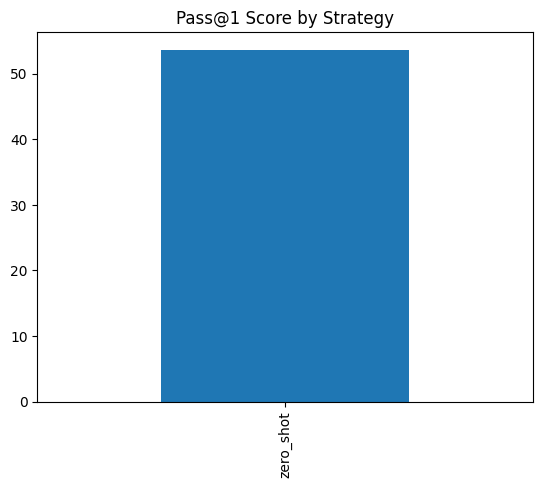

In [ ]:
import pandas as pd

df = pd.DataFrame(results_summary).T
print(df)

# Optional: Plotting
try:
    df['pass@1'].plot(kind='bar', title='Pass@1 Score by Strategy')
except ImportError:
    pass